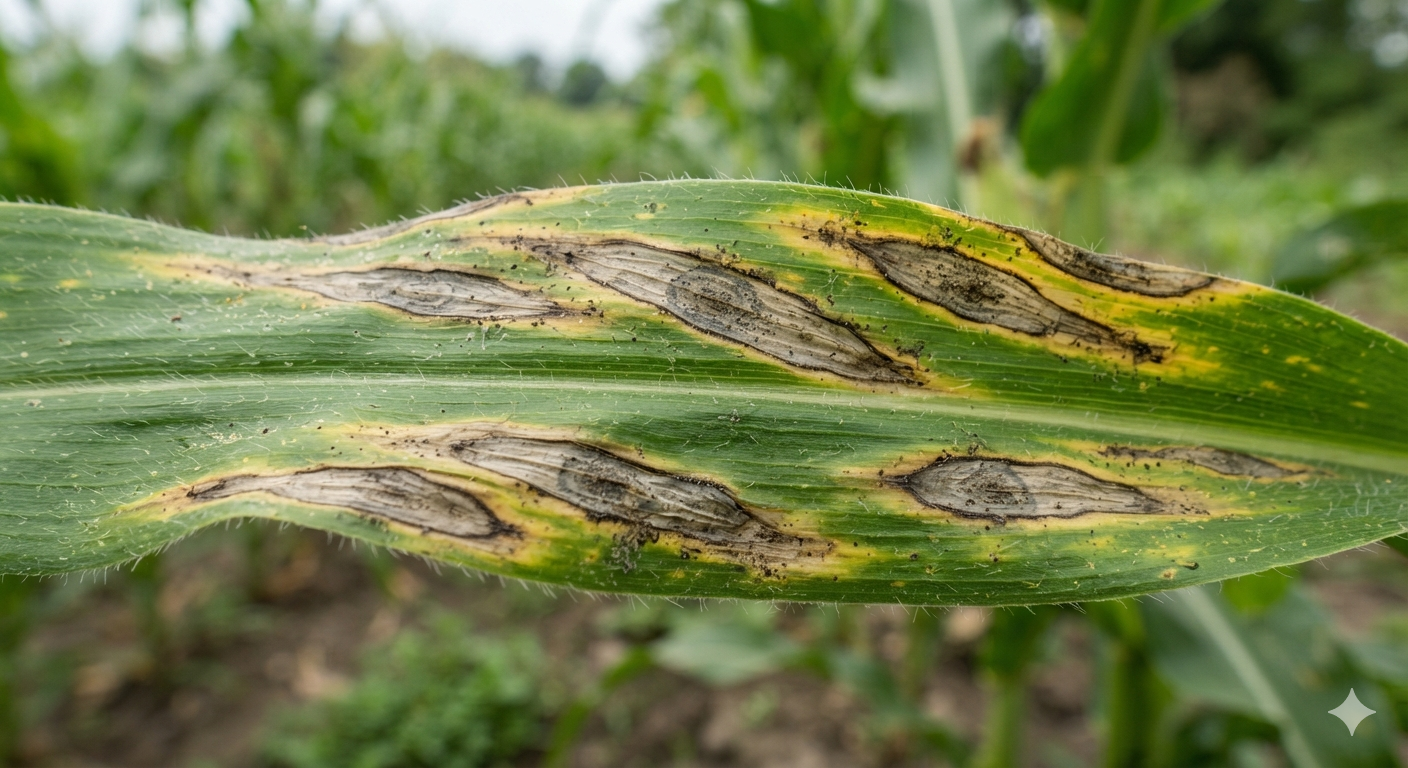


# Corn Leaf Disease Classification: CRISP-DM Plan

This notebook documents the project from business understanding through data preparation. The task is multiclass image classification with four classes: **Blight**, **Common_Rust**, **Gray_Leaf_Spot**, and **Healthy**.

Project Overview

This project develops a deep-learning image classifier for detecting corn leaf conditions: Blight, Common Rust, Gray Leaf Spot, and Healthy. Following CRISP-DM, the images are cleaned, converted to RGB, resized , and split into training and validation sets. A baseline CNN is compared with a pretrained model such as MobileNetV2 or EfficientNetB0. Performance is measured using accuracy, macro F1-score, per-class recall, precision, and a confusion matrix. The final system is designed to support farmers and agronomists with fast preliminary disease screening, while expert confirmation remains necessary.



## 1. Business Understanding

### Business problem
Corn diseases can reduce yield and quality when they are detected late. Field diagnosis may be slow, inconsistent, or dependent on access to an experienced agronomist. A computer-vision classifier can provide an early screening signal from a photograph of a corn leaf.

### Problem statement
Develop and evaluate an image-classification model that predicts the visible condition of a corn leaf as Blight, Common Rust, Gray Leaf Spot, or Healthy. The model should support rapid, repeatable screening while clearly communicating that predictions are decision support rather than a replacement for expert confirmation.

### Objectives

| Objective | Description | Deliverable |
|---|---|---|
| Classify leaf images | Predict one of four disease/health classes | Trained multiclass classifier |
| Reduce missed disease | Prioritize recall for disease classes, especially in field screening | Per-class recall and confusion matrix |
| Produce trustworthy probabilities | Return confidence scores and flag uncertain cases | Calibrated probabilities or an uncertainty threshold |
| Make the workflow reproducible | Use a documented local path, fixed seed, split, and preprocessing pipeline | Re-runnable notebook |
| Support practical use | Keep inference fast enough for an image-upload workflow | Inference-time and model-size measurements |

### Stakeholders and their interests

| Stakeholder | Interest | What success means for them |
|---|---|---|
| Farmers and field scouts | Fast, accessible disease screening | Correct early alerts and few missed diseased leaves |
| Agronomists and extension officers | A consistent second opinion | Useful explanations, confidence scores, and easy review of uncertain images |
| Agribusiness and crop advisors | Scalable crop-health monitoring | Lower inspection cost and reliable performance across farms |
| Researchers and students | Reproducible experimentation | Transparent data splits, methods, metrics, and limitations |
| Product or deployment team | Maintainable local or web inference | Stable preprocessing, acceptable latency, and versioned models |
| Crop policy and food-security planners | Early visibility of disease patterns | Aggregated, reliable signals without overstating model certainty |

### Value of automation

Automation enables rapid screening of many images, consistent application of the same decision rule, lower manual inspection effort, and earlier escalation to an expert. It is most valuable as a triage layer: high-confidence cases can be prioritized while low-confidence or unusual images are referred for human diagnosis.



## 2. Data Understanding

### Dataset profile and working assumption

| Item | Project value / assumption |
|---|---|
| Class names | Blight, Common_Rust, Gray_Leaf_Spot, Healthy |
| Original image dimensions | Audited from the files; images may have different dimensions |
| Resized dimensions | 224 x 224 pixels, RGB, for a practical transfer-learning baseline |
| Class balance | Imbalanced; Gray_Leaf_Spot is the smallest class |
| Training split | 80% of images, stratified by class |
| Validation split | 20% of images, stratified by class |
| Total source images | 4,188 in the current local dataset audit |
| Expected training images | Computed by the audit cell, approximately 3,350 |
| Expected validation images | Computed by the audit cell, approximately 838 |
| Label type | Single-label multiclass classification |
| Leakage control | Split by image before augmentation; do not place near-duplicate images in both splits |



2.1 Importing the libraries

In [27]:
#Step 1 — Import the libraries
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import os
import shutil
import hashlib
from pathlib import Path
from collections import Counter
from PIL import Image
from IPython.display import display
import tensorflow as tf
from tensorflow import keras
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers



2.2 . Data overview

In [28]:
# Build audit_df before running the Data Understanding cells.
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
DATA_CANDIDATES = [
    Path.cwd() / "data",
]
DATA_DIR = next((path for path in DATA_CANDIDATES if path.is_dir()), None)
if DATA_DIR is None:
    raise FileNotFoundError("Dataset folder not found. Check DATA_CANDIDATES.")

records = []
unreadable_images = []

for class_dir in sorted(path for path in DATA_DIR.iterdir() if path.is_dir()):
    for image_path in sorted(class_dir.iterdir()):
        if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue
        try:
            with Image.open(image_path) as image:
                image.verify()
            with Image.open(image_path) as image:
                records.append({
                    "path": str(image_path),
                    "class_name": class_dir.name,
                    "width": image.width,
                    "height": image.height,
                    "channels": len(image.getbands()),
                    "format": image.format,
                    "color_mode": image.mode,
                })
        except (OSError, ValueError):
            unreadable_images.append(str(image_path))

audit_df = pd.DataFrame(records)
if audit_df.empty:
    raise ValueError(f"No readable images found under {DATA_DIR}")

class_names = sorted(audit_df["class_name"].unique())
print(f"Audited readable images: {len(audit_df):,}")
print(f"Unreadable images: {len(unreadable_images)}")

Audited readable images: 4,188
Unreadable images: 0


In [29]:
print("Total valid images:", len(audit_df))
print("Number of classes:", audit_df["class_name"].nunique())
print("Classes:", sorted(audit_df["class_name"].unique()))

display(audit_df.head())

print("\nDataset information:")
audit_df.info()

Total valid images: 4188
Number of classes: 4
Classes: ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']


,path,class_name,width,height,channels,format,color_mode
0,c:\Users\admin\Downloads\Capstone Project\data...,Blight,1000,585,3,JPEG,RGB
1,c:\Users\admin\Downloads\Capstone Project\data...,Blight,788,371,3,JPEG,RGB
2,c:\Users\admin\Downloads\Capstone Project\data...,Blight,641,482,3,JPEG,RGB
3,c:\Users\admin\Downloads\Capstone Project\data...,Blight,300,200,3,JPEG,RGB
4,c:\Users\admin\Downloads\Capstone Project\data...,Blight,256,256,3,JPEG,RGB



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 4188 entries, 0 to 4187
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   path        4188 non-null   str  
 1   class_name  4188 non-null   str  
 2   width       4188 non-null   int64
 3   height      4188 non-null   int64
 4   channels    4188 non-null   int64
 5   format      4188 non-null   str  
 6   color_mode  4188 non-null   str  
dtypes: int64(3), str(4)
memory usage: 229.2 KB


2.3 Image metadata distribution

In [30]:
print("Image formats:")
display(audit_df["format"].value_counts())

print("Color modes:")
display(audit_df["color_mode"].value_counts())

print("Image dimensions:")
display(audit_df[["width", "height"]].describe())

Image formats:


format
JPEG    4183
PNG        4
MPO        1
Name: count, dtype: int64

Color modes:


color_mode
RGB     4183
RGBA       4
CMYK       1
Name: count, dtype: int64

Image dimensions:


,width,height
count,4188.000000,4188.000000
mean,307.536533,297.906160
std,285.716933,253.138674
min,180.000000,116.000000
25%,256.000000,256.000000
50%,256.000000,256.000000
75%,256.000000,256.000000
max,5184.000000,5184.000000


2.4  Check missing metadata

In [31]:
missing_values = audit_df.isnull().sum()

print("Missing values by column:")
display(missing_values)

print("Total missing values:", missing_values.sum())

Missing values by column:


path          0
class_name    0
width         0
height        0
channels      0
format        0
color_mode    0
dtype: int64

Total missing values: 0


2.5 Image metadata distribution

In [32]:
print("Image formats:")
display(audit_df["format"].value_counts())

print("Color modes:")
display(audit_df["color_mode"].value_counts())

print("Image dimensions:")
display(audit_df[["width", "height"]].describe())

Image formats:


format
JPEG    4183
PNG        4
MPO        1
Name: count, dtype: int64

Color modes:


color_mode
RGB     4183
RGBA       4
CMYK       1
Name: count, dtype: int64

Image dimensions:


,width,height
count,4188.000000,4188.000000
mean,307.536533,297.906160
std,285.716933,253.138674
min,180.000000,116.000000
25%,256.000000,256.000000
50%,256.000000,256.000000
75%,256.000000,256.000000
max,5184.000000,5184.000000


2.6 Check image quality and file sizes

In [33]:
from pathlib import Path

quality_df = audit_df.copy()

quality_df["file_size_kb"] = quality_df["path"].apply(
    lambda path: Path(path).stat().st_size / 1024
)

quality_df["aspect_ratio"] = (
    quality_df["width"] / quality_df["height"]
)

quality_df["image_area"] = (
    quality_df["width"] * quality_df["height"]
)

display(quality_df[
    ["width", "height", "file_size_kb", "aspect_ratio", "image_area"]
].describe().round(2))

,width,height,file_size_kb,aspect_ratio,image_area
count,4188.00,4188.00,4188.00,4188.00,4188.00
mean,307.54,297.91,38.46,1.02,156855.33
std,285.72,253.14,218.26,0.16,811837.53
min,180.00,116.00,3.12,0.29,33872.00
25%,256.00,256.00,11.40,1.00,65536.00
50%,256.00,256.00,13.52,1.00,65536.00
75%,256.00,256.00,15.56,1.00,65536.00
max,5184.00,5184.00,6331.98,3.75,17915904.00


In [34]:
quality_df["file_size_kb"] = quality_df["path"].apply(
    lambda path: Path(path).stat().st_size / 1024
)

2.6.1 Check unreadable files


In [35]:
print("Unreadable images:", len(unreadable_images))

if unreadable_images:
    display(pd.DataFrame({"unreadable_filepath": unreadable_images}))
else:
    print("No unreadable images detected.")

Unreadable images: 0
No unreadable images detected.


2.7 Class balance

In [36]:
class_counts = (
    audit_df["class_name"]
    .value_counts()
    .reindex(class_names, fill_value=0)
)

class_balance_df = pd.DataFrame({
    "class": class_counts.index,
    "image_count": class_counts.values,
    "percentage": (class_counts.values / class_counts.sum() * 100).round(2)
})

display(class_balance_df)

,class,image_count,percentage
0,Blight,1146,27.36
1,Common_Rust,1306,31.18
2,Gray_Leaf_Spot,574,13.71
3,Healthy,1162,27.75


2.8  Visualize class distribution

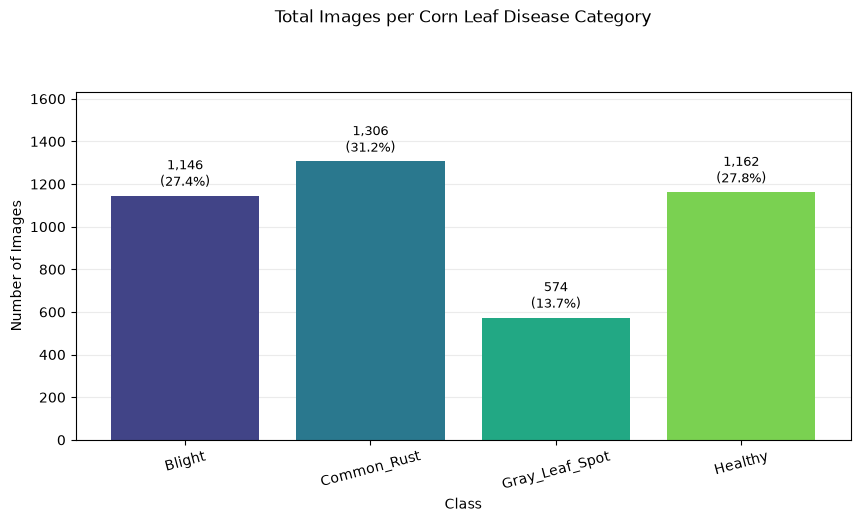

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    class_balance_df["class"],
    class_balance_df["image_count"],
    color=sns.color_palette("viridis", n_colors=len(class_balance_df)),
)

max_count = class_balance_df["image_count"].max()
label_offset = max_count * 0.02

for bar, count, percentage in zip(
    bars,
    class_balance_df["image_count"],
    class_balance_df["percentage"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        count + label_offset,
        f"{count:,}\n({percentage:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_ylim(0, max_count * 1.25)
ax.set_title(
    "Total Images per Corn Leaf Disease Category",
    y=1.16,
    pad=10,
)
ax.set_xlabel("Class")
ax.set_ylabel("Number of Images")
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

fig.subplots_adjust(top=0.76, bottom=0.18)
plt.show()

Inspect sample images

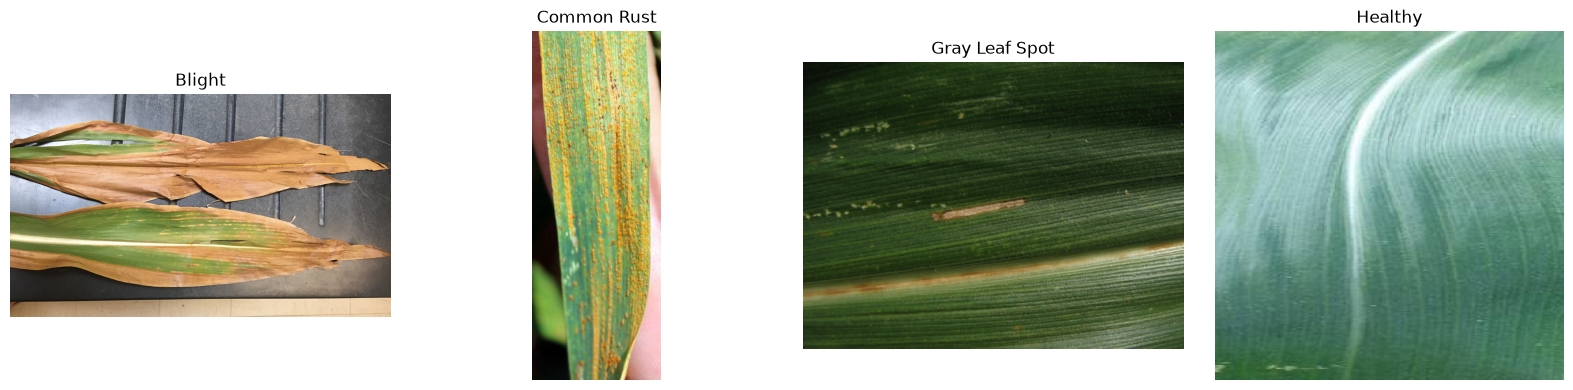

In [38]:
DATA_DIR = Path.cwd() / "data"
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Exclude non-class folders such as "assets"
class_dirs = [
    folder for folder in sorted(DATA_DIR.iterdir())
    if folder.is_dir() and folder.name != "assets"
]

fig, axes = plt.subplots(1, len(class_dirs), figsize=(4 * len(class_dirs), 4))
axes = axes.ravel()

for axis, class_dir in zip(axes, class_dirs):
    image_paths = [
        path for path in class_dir.iterdir()
        if path.suffix.lower() in IMAGE_EXTENSIONS
    ]

    if not image_paths:
        axis.set_title(f"{class_dir.name}\nNo images found")
        axis.axis("off")
        continue

    image_path = image_paths[0]  # Change to another index, if desired

    with Image.open(image_path) as image:
        axis.imshow(image.convert("RGB"))

    axis.set_title(class_dir.name.replace("_", " "))
    axis.axis("off")

plt.tight_layout()
plt.show()

2.9 Diagnose class imbalance

In [39]:
largest_class = class_counts.max()
smallest_class = class_counts.min()

imbalance_ratio = largest_class / smallest_class

print("Largest class:", class_counts.idxmax(), largest_class)
print("Smallest class:", class_counts.idxmin(), smallest_class)
print(f"Imbalance ratio: {imbalance_ratio:.2f}")

if imbalance_ratio > 1.5:
    print("The dataset is imbalanced. Use class weights or balanced sampling.")
else:
    print("The class distribution is relatively balanced.")

Largest class: Common_Rust 1306
Smallest class: Gray_Leaf_Spot 574
Imbalance ratio: 2.28
The dataset is imbalanced. Use class weights or balanced sampling.


2.9.1 Analyze geometric properties

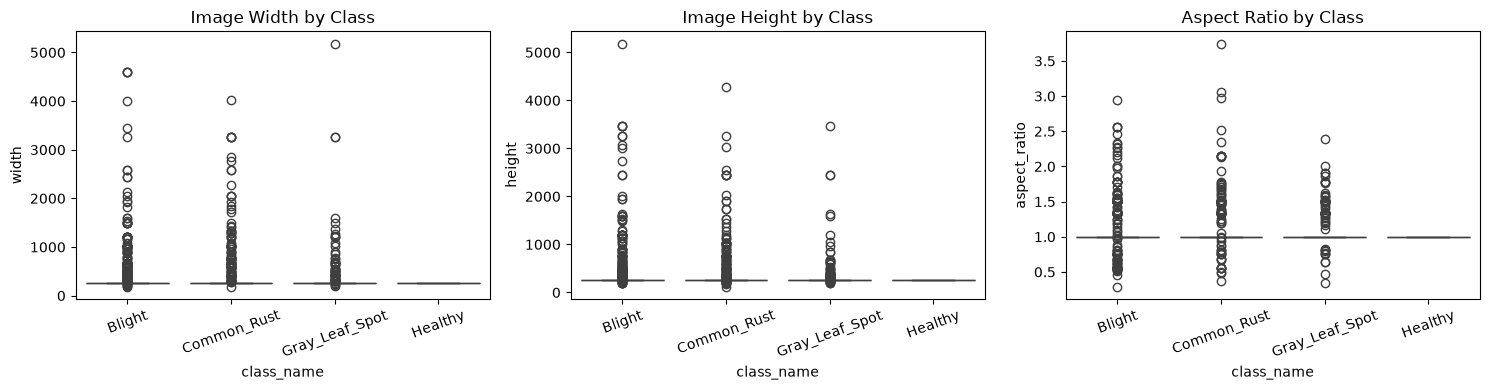

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=quality_df, x="class_name", y="width", ax=axes[0])
axes[0].set_title("Image Width by Class")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(data=quality_df, x="class_name", y="height", ax=axes[1])
axes[1].set_title("Image Height by Class")
axes[1].tick_params(axis="x", rotation=20)

sns.boxplot(data=quality_df, x="class_name", y="aspect_ratio", ax=axes[2])
axes[2].set_title("Aspect Ratio by Class")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

Find unusual geometric images:

In [41]:
low_resolution_images = quality_df[
    (quality_df["width"] < 100) |
    (quality_df["height"] < 100)
]

extreme_aspect_images = quality_df[
    (quality_df["aspect_ratio"] < 0.5) |
    (quality_df["aspect_ratio"] > 2.0)
]

print("Low-resolution images:", len(low_resolution_images))
print("Extreme-aspect-ratio images:", len(extreme_aspect_images))

display(low_resolution_images.head())
display(extreme_aspect_images.head())

Low-resolution images: 0
Extreme-aspect-ratio images: 30


,path,class_name,width,height,channels,format,color_mode,file_size_kb,aspect_ratio,image_area


,path,class_name,width,height,channels,format,color_mode,file_size_kb,aspect_ratio,image_area
1,c:\Users\admin\Downloads\Capstone Project\data...,Blight,788,371,3,JPEG,RGB,76.775391,2.123989,292348
14,c:\Users\admin\Downloads\Capstone Project\data...,Blight,1080,421,3,JPEG,RGB,226.377930,2.565321,454680
25,c:\Users\admin\Downloads\Capstone Project\data...,Blight,1489,3264,3,JPEG,RGB,1113.178711,0.456189,4860096
122,c:\Users\admin\Downloads\Capstone Project\data...,Blight,884,3071,3,JPEG,RGB,379.745117,0.287854,2714764
141,c:\Users\admin\Downloads\Capstone Project\data...,Blight,896,407,3,JPEG,RGB,94.029297,2.201474,364672


2.9.2  Analyze brightness, contrast, saturation, and sharpness

In [42]:
def calculate_visual_features(image_path):
    with Image.open(image_path) as image:
        image = image.convert("RGB").resize((128, 128))

        rgb = np.asarray(image).astype("float32") / 255.0
        grayscale = np.asarray(image.convert("L")).astype("float32") / 255.0
        hsv = np.asarray(image.convert("HSV")).astype("float32") / 255.0

        horizontal_edges = np.diff(grayscale, axis=1)
        vertical_edges = np.diff(grayscale, axis=0)

        return {
            "brightness": rgb.mean(),
            "contrast": grayscale.std(),
            "saturation": hsv[:, :, 1].mean(),
            "red_mean": rgb[:, :, 0].mean(),
            "green_mean": rgb[:, :, 1].mean(),
            "blue_mean": rgb[:, :, 2].mean(),
            "sharpness_proxy": np.std(
                np.concatenate([
                    horizontal_edges.ravel(),
                    vertical_edges.ravel()
                ])
            )
        }

visual_features = []

for _, row in audit_df.iterrows():
    try:
        features = calculate_visual_features(row["path"])
        features["class_name"] = row["class_name"]
        features["path"] = row["path"]
        visual_features.append(features)
    except (OSError, ValueError):
        pass

visual_df = pd.DataFrame(visual_features)

display(
    visual_df.groupby("class_name")[
        [
            "brightness",
            "contrast",
            "saturation",
            "red_mean",
            "green_mean",
            "blue_mean",
            "sharpness_proxy"
        ]
    ].mean().round(3)
)

,brightness,contrast,saturation,red_mean,green_mean,blue_mean,sharpness_proxy
class_name,,,,,,,
Blight,0.438,0.127,0.286,0.449,0.481,0.383,0.044
Common_Rust,0.343,0.240,0.289,0.359,0.391,0.278,0.058
Gray_Leaf_Spot,0.442,0.140,0.291,0.459,0.487,0.381,0.053
Healthy,0.540,0.125,0.322,0.504,0.640,0.476,0.035


**3. DATA PREPARATION**

Transform audited images into clean, standardized, leak-free tensors for modeling.

In [43]:
# Identify and remove perceptually similar duplicate images using imagehash.
import subprocess
import sys

# Install imagehash if not already installed.
try:
    import imagehash
except ImportError:
    print("Installing imagehash...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imagehash", "-q"])
    import imagehash

# Compute perceptual hashes for all images.
hash_size = 8
hashes = {}
hash_errors = []

for idx, row in audit_df.iterrows():
    image_path = row["path"]
    try:
        with Image.open(image_path) as image:
            # Convert to RGB to ensure consistent hashing.
            rgb_image = image.convert("RGB")
            # Compute difference hash (fast and effective for most duplicates).
            p_hash = imagehash.dhash(rgb_image, hash_size=hash_size)
            hashes[image_path] = p_hash
    except Exception as e:
        hash_errors.append((image_path, str(e)))

print(f"Computed hashes for {len(hashes):,} images")
print(f"Hash computation errors: {len(hash_errors)}")

# Find duplicates by comparing Hamming distances between hashes.
# A distance of 0-5 indicates very similar or identical images (threshold tunable).
SIMILARITY_THRESHOLD = 5  # Hamming distance threshold
duplicate_groups = []
processed_paths = set()

for path1, hash1 in hashes.items():
    if path1 in processed_paths:
        continue
    group = [path1]
    for path2, hash2 in hashes.items():
        if path1 != path2 and path2 not in processed_paths:
            distance = hash1 - hash2
            if distance <= SIMILARITY_THRESHOLD:
                group.append(path2)
                processed_paths.add(path2)
    if len(group) > 1:
        duplicate_groups.append(group)
        for p in group:
            processed_paths.add(p)

print(f"Duplicate groups found: {len(duplicate_groups)}")
total_duplicates = sum(len(g) - 1 for g in duplicate_groups)
print(f"Total duplicate images (to remove): {total_duplicates}")

# Keep the first image from each duplicate group; mark others for removal.
paths_to_remove = []
for group in duplicate_groups:
    # Sort by file size (keep the largest as it may be higher quality).
    group_with_sizes = [(p, Path(p).stat().st_size) for p in group]
    group_with_sizes.sort(key=lambda x: x[1], reverse=True)
    kept_path = group_with_sizes[0][0]
    for duplicate_path, _ in group_with_sizes[1:]:
        paths_to_remove.append(duplicate_path)

# Create deduplicated dataframe.
deduplicated_df = audit_df[~audit_df["path"].isin(paths_to_remove)].copy()

print(f"\nDeduplication summary:")
print(f"Original images: {len(audit_df):,}")
print(f"After removing duplicates: {len(deduplicated_df):,}")
print(f"Images removed: {len(audit_df) - len(deduplicated_df):,}")

print("\nPer-class comparison:")
comparison = pd.DataFrame({
    "original": audit_df["class_name"].value_counts(),
    "after_dedup": deduplicated_df["class_name"].value_counts()
}).fillna(0).astype(int)
display(comparison)

Computed hashes for 4,188 images
Hash computation errors: 0
Duplicate groups found: 22
Total duplicate images (to remove): 23

Deduplication summary:
Original images: 4,188
After removing duplicates: 4,165
Images removed: 23

Per-class comparison:


,original,after_dedup
class_name,,
Common_Rust,1306,1299
Healthy,1162,1158
Blight,1146,1137
Gray_Leaf_Spot,574,571


### 3.1 Clean duplicates and encode labels

In [44]:
def calculate_hash(path):
    with open(path, "rb") as file:
        return hashlib.sha256(file.read()).hexdigest()

# Start from the perceptually deduplicated dataframe when that cell has run.
source_df = deduplicated_df if "deduplicated_df" in globals() else audit_df
prepared_df = source_df.copy()
prepared_df["image_hash"] = prepared_df["path"].apply(calculate_hash)

# Step 1: Identify hashes with conflicting labels (same image, different disease classes)
hash_label_counts = prepared_df.groupby("image_hash")["class_name"].nunique()
conflicting_hashes = hash_label_counts[hash_label_counts > 1].index

print(f"Hashes with conflicting labels (same image, different classes): {len(conflicting_hashes)}")

# Step 2: Remove images with conflicting labels
clean_df = prepared_df[~prepared_df["image_hash"].isin(conflicting_hashes)].copy()

# Step 3: Remove exact duplicates (keep only the first occurrence of each hash)
duplicates_count = len(clean_df[clean_df.duplicated(subset=['image_hash'], keep=False)])
clean_df = clean_df.drop_duplicates(subset=['image_hash'], keep='first').copy()

# Step 4: Add label encoding
label_to_id = {name: index for index, name in enumerate(class_names)}
clean_df["label_id"] = clean_df["class_name"].map(label_to_id).astype("int32")

print("\n" + "="*60)
print("DATA CLEANING SUMMARY")
print("="*60)
print(f"Original audited images: {len(audit_df):,}")
print(f"After perceptual deduplication: {len(source_df):,}")
print(f"  → Perceptual duplicates removed: {len(audit_df) - len(source_df):,}")
print(f"\nBefore exact-hash cleaning: {len(prepared_df):,}")
print(f"  → Images removed (conflicting labels): {len(conflicting_hashes):,}")
print(f"  → Exact duplicates removed: {duplicates_count // 2 if duplicates_count > 0 else 0:,}")
print(f"After exact-hash cleaning and label encoding: {len(clean_df):,}")
print(f"  → Total images removed: {len(prepared_df) - len(clean_df):,}")
print("="*60)

print("\nFinal dataset by class:")
display(clean_df["class_name"].value_counts().reindex(class_names, fill_value=0))


Hashes with conflicting labels (same image, different classes): 0

DATA CLEANING SUMMARY
Original audited images: 4,188
After perceptual deduplication: 4,165
  → Perceptual duplicates removed: 23

Before exact-hash cleaning: 4,165
  → Images removed (conflicting labels): 0
  → Exact duplicates removed: 0
After exact-hash cleaning and label encoding: 4,165
  → Total images removed: 0

Final dataset by class:


class_name
Blight            1137
Common_Rust       1299
Gray_Leaf_Spot     571
Healthy           1158
Name: count, dtype: int64

### 3.2 Stratified splitting and leakage prevention

### 3.1.1 Reproducible split settings

These settings keep the train/validation split consistent every time the notebook runs.

In [45]:
RANDOM_STATE = 42
VALIDATION_SIZE = 0.20


In [46]:
train_df, validation_df = train_test_split(
    clean_df, test_size=VALIDATION_SIZE, random_state=RANDOM_STATE,
    stratify=clean_df["label_id"]
)

train_hashes = set(train_df["image_hash"])
validation_hashes = set(validation_df["image_hash"])
print("Exact hash overlap:", len(train_hashes & validation_hashes))

split_summary = pd.DataFrame({
    "training_images": train_df["class_name"].value_counts(),
    "validation_images": validation_df["class_name"].value_counts(),
}).reindex(class_names, fill_value=0)
display(split_summary)

Exact hash overlap: 0


,training_images,validation_images
class_name,,
Blight,910,227
Common_Rust,1039,260
Gray_Leaf_Spot,457,114
Healthy,926,232


### 3.2.1 Class weights for imbalance

Use class weights instead of oversampling first. This reduces bias toward the larger classes while keeping validation data untouched.

In [47]:
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label_id"]),
    y=train_df["label_id"]
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(np.unique(train_df["label_id"]), class_weight_values)
}

print("Class weights used during training:")
for class_name, class_id in label_to_id.items():
    print(f"{class_id} - {class_name}: {class_weights[class_id]:.3f}")


Class weights used during training:
0 - Blight: 0.915
1 - Common_Rust: 0.802
2 - Gray_Leaf_Spot: 1.823
3 - Healthy: 0.900


### 3.3 RGB conversion, aspect-ratio-preserving resize, batching, and prefetching

In [48]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_prepare_image(path, label_id):
    image = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    # Padding preserves aspect ratio and prevents leaf distortion.
    image = tf.image.resize_with_pad(image, IMAGE_SIZE[0], IMAGE_SIZE[1])
    return tf.cast(image, tf.float32), label_id

def create_dataset(dataframe, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((dataframe["path"].values, dataframe["label_id"].values))
    dataset = dataset.map(load_and_prepare_image, num_parallel_calls=AUTOTUNE)
    if shuffle:
        dataset = dataset.shuffle(len(dataframe), seed=RANDOM_STATE, reshuffle_each_iteration=True)
    return dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = create_dataset(train_df, shuffle=True)
validation_ds = create_dataset(validation_df)
sample_images, sample_labels = next(iter(train_ds.take(1)))
print("Batch shape:", sample_images.shape)
print("Pixel range before model normalization:", float(tf.reduce_min(sample_images)), float(tf.reduce_max(sample_images)))

Batch shape: (32, 224, 224, 3)
Pixel range before model normalization: 0.0 255.0


### 3.4 Normalization and training-only augmentation

Keep validation images untouched. Apply normalization inside the model so the same transformation is used during inference.

In [49]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.10),
], name="training_augmentation")

# Basic CNN: use layers.Rescaling(1 / 255.0) after augmentation.
# MobileNetV2: use its 0–255 to -1–1 preprocessing instead.
print("Augmentation layer ready; use it only in the training model path.")

Augmentation layer ready; use it only in the training model path.


### 3.5 Label encoding verification

Integer labels work with SparseCategoricalCrossentropy. One-hot encoding is optional.


In [50]:
train_one_hot = tf.keras.utils.to_categorical(train_df["label_id"], len(class_names))
validation_one_hot = tf.keras.utils.to_categorical(validation_df["label_id"], len(class_names))
print("Integer label example:", train_df["label_id"].iloc[0])
print("One-hot label example:", train_one_hot[0])
print("Missing values after preparation:", int(clean_df.isnull().sum().sum()))

Integer label example: 2
One-hot label example: [0. 0. 1. 0.]
Missing values after preparation: 0


# 4. Modeling

## 4.1 Modeling Strategy

This project develops and compares three deep learning models for corn leaf disease classification:

1. **Baseline CNN**
   - A simple Convolutional Neural Network used to establish an initial performance benchmark.

2. **Improved CNN**
   - An enhanced custom CNN that incorporates data augmentation, batch normalization, additional convolutional layers, global average pooling, and dropout to improve generalization.

3. **MobileNetV2 Transfer Learning**
   - A pretrained deep learning model used to leverage previously learned visual features for image classification.

The models will be compared during the evaluation stage using validation accuracy, Macro F1-score, classification performance across individual classes, and training behaviour.

The best-performing model will be selected as the final model for the automated corn leaf disease classification system.


## 6. Reproducible experiment setup

This section restarts the modeling experiment after 5.6 using the perceptually deduplicated dataset (4,165 images). All three models use the same stratified train/validation/test split, so their comparison is fair.

**Why this matters:** a separate test set estimates performance on unseen leaves, while stratification keeps every disease class represented in each split. The test set is used only after training.


### 6.1 Create a leak-resistant train/validation/test split

The split is stratified so every disease class appears in all partitions. The perceptual-hash cleaning already removed near-duplicate leaves, reducing data leakage.

In [56]:
import hashlib
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

experiment_df = (
    deduplicated_df.copy()
    if "deduplicated_df" in globals()
    else clean_df.copy()
    if "clean_df" in globals()
    else source_df.copy()
)

if "image_hash" not in experiment_df.columns:
    if "calculate_hash" not in globals():
        def calculate_hash(path):
            with open(path, "rb") as file:
                return hashlib.sha256(file.read()).hexdigest()
    experiment_df["image_hash"] = experiment_df["path"].map(calculate_hash)
experiment_df = experiment_df.drop_duplicates(subset=["image_hash"]).copy()
class_names = sorted(experiment_df["class_name"].unique())
label_to_id = {name: index for index, name in enumerate(class_names)}
experiment_df["label_id"] = experiment_df["class_name"].map(label_to_id).astype("int32")
num_classes = len(class_names)

train_validation_df, test_df = train_test_split(
    experiment_df, test_size=0.15, random_state=SEED,
    stratify=experiment_df["label_id"]
)
train_df_v2, validation_df_v2 = train_test_split(
    train_validation_df, test_size=0.1765, random_state=SEED,
    stratify=train_validation_df["label_id"]
)

print(f"Total images: {len(experiment_df):,}")
print(f"Training: {len(train_df_v2):,} | Validation: {len(validation_df_v2):,} | Test: {len(test_df):,}")
display(pd.DataFrame({
    "train": train_df_v2["class_name"].value_counts(),
    "validation": validation_df_v2["class_name"].value_counts(),
    "test": test_df["class_name"].value_counts(),
}).reindex(class_names).fillna(0).astype(int))

Total images: 4,165
Training: 2,915 | Validation: 625 | Test: 625


,train,validation,test
class_name,,,
Blight,796,171,170
Common_Rust,909,195,195
Gray_Leaf_Spot,400,85,86
Healthy,810,174,174


### 6.2 Build shared datasets and class weights

All models use the same resized RGB tensors. Class weights reduce the effect of unequal class counts during training without changing the test set.

In [54]:
IMAGE_SIZE_V2 = (160, 160)
BATCH_SIZE_V2 = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_experiment_image(path, label_id):
    image = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize_with_pad(image, IMAGE_SIZE_V2[0], IMAGE_SIZE_V2[1])
    return tf.cast(image, tf.float32), tf.cast(label_id, tf.int32)

def make_experiment_dataset(dataframe, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices(
        (dataframe["path"].values, dataframe["label_id"].values)
    )
    dataset = dataset.map(load_experiment_image, num_parallel_calls=AUTOTUNE)
    if shuffle:
        dataset = dataset.shuffle(len(dataframe), seed=SEED, reshuffle_each_iteration=True)
    return dataset.batch(BATCH_SIZE_V2).prefetch(AUTOTUNE)

train_ds_v2 = make_experiment_dataset(train_df_v2, shuffle=True)
validation_ds_v2 = make_experiment_dataset(validation_df_v2)
test_ds_v2 = make_experiment_dataset(test_df)

class_weight_values = compute_class_weight(
    class_weight="balanced", classes=np.arange(num_classes), y=train_df_v2["label_id"]
)
class_weights_v2 = dict(enumerate(class_weight_values.astype(float)))
os.makedirs("artifacts", exist_ok=True)
print("Class weights:", {class_names[k]: round(v, 3) for k, v in class_weights_v2.items()})

Class weights: {'Blight': np.float64(0.916), 'Common_Rust': np.float64(0.802), 'Gray_Leaf_Spot': np.float64(1.822), 'Healthy': np.float64(0.9)}


### 6.3 Training policy: maximum epochs with early stopping

Twenty epochs is not required. A maximum of 12 epochs is used here, while early stopping restores the best validation weights when validation loss stops improving. This makes the training budget evidence-based rather than arbitrary.

In [55]:
MAX_EPOCHS_V2 = 12

def make_callbacks(model_name):
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=3, restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=1, min_lr=1e-6, verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            f"artifacts/{model_name}_v2_best.keras", monitor="val_loss",
            save_best_only=True, verbose=0
        ),
    ]

## 7. Compact baseline CNN

### 7.1 Build the baseline CNN

This baseline is intentionally small for 4,165 images. Global Average Pooling replaces flattening, avoiding the millions of parameters caused by connecting every spatial feature to a dense layer.

In [57]:
baseline_cnn_v2 = keras.Sequential([
    keras.Input(shape=(*IMAGE_SIZE_V2, 3)),
    layers.Rescaling(1.0 / 255.0),
    layers.Conv2D(16, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.35),
    layers.Dense(num_classes, activation="softmax"),
], name="compact_baseline_cnn")
baseline_cnn_v2.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)
baseline_cnn_v2.summary()
print(f"Trainable parameters: {baseline_cnn_v2.count_params():,}")

Model: "compact_baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,004 (109.39 KB)

 Trainable params: 28,004 (109.39 KB)

 Non-trainable params: 0 (0.00 B)

Trainable parameters: 28,004


### 7.2 Train the baseline CNN

In [58]:
baseline_history_v2 = baseline_cnn_v2.fit(
    train_ds_v2, validation_data=validation_ds_v2, epochs=MAX_EPOCHS_V2,
    class_weight=class_weights_v2, callbacks=make_callbacks("compact_baseline_cnn")
)

Epoch 1/12


c:\Users\admin\anaconda3\envs\machine-learning-task\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


92/92 ━━━━━━━━━━━━━━━━━━━━ 43s 242ms/step - accuracy: 0.5081 - loss: 1.1029 - val_accuracy: 0.6848 - val_loss: 0.7255 - learning_rate: 0.0010
Epoch 2/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 237ms/step - accuracy: 0.6998 - loss: 0.7331 - val_accuracy: 0.7600 - val_loss: 0.5248 - learning_rate: 0.0010
Epoch 3/12
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.7483 - loss: 0.6523
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
92/92 ━━━━━━━━━━━━━━━━━━━━ 39s 223ms/step - accuracy: 0.7485 - loss: 0.6517 - val_accuracy: 0.7008 - val_loss: 0.5653 - learning_rate: 0.0010
Epoch 4/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 29s 226ms/step - accuracy: 0.7451 - loss: 0.6200 - val_accuracy: 0.7520 - val_loss: 0.4825 - learning_rate: 5.0000e-04
Epoch 5/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 26s 215ms/step - accuracy: 0.7640 - loss: 0.5998 - val_accuracy: 0.7504 - val_loss: 0.4810 - learning_rate: 5.0000e-04
Epoch 6/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 27s 217ms/step - accuracy: 0.7530 - loss: 0.5964 

## 8. Improved CNN

### 8.1 Build the improved CNN

Light augmentation, batch normalization, and dropout improve generalization while the GAP head keeps the model compact.

In [59]:
data_augmentation_v2 = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
], name="training_augmentation_v2")

improved_cnn_v2 = keras.Sequential([
    keras.Input(shape=(*IMAGE_SIZE_V2, 3)), data_augmentation_v2,
    layers.Rescaling(1.0 / 255.0),
    layers.Conv2D(24, 3, padding="same", use_bias=False),
    layers.BatchNormalization(), layers.Activation("relu"), layers.MaxPooling2D(),
    layers.Conv2D(48, 3, padding="same", use_bias=False),
    layers.BatchNormalization(), layers.Activation("relu"), layers.MaxPooling2D(),
    layers.Conv2D(96, 3, padding="same", use_bias=False),
    layers.BatchNormalization(), layers.Activation("relu"),
    layers.GlobalAveragePooling2D(), layers.Dense(96, activation="relu"),
    layers.Dropout(0.45), layers.Dense(num_classes, activation="softmax"),
], name="improved_cnn_gap")
improved_cnn_v2.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)
improved_cnn_v2.summary()
print(f"Trainable parameters: {improved_cnn_v2.count_params():,}")

Model: "improved_cnn_gap"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ training_augmentation_v2        │ (None, 160, 160, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 160, 160, 24)   │           648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 160, 24)   │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 160, 160, 24)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 80, 80, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 80, 80, 48)     │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 80, 80, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 80, 80, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 40, 40, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 40, 40, 96)     │        41,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 40, 40, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 40, 40, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 96)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 96)             │         9,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           388 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,860 (245.55 KB)

 Trainable params: 62,524 (244.23 KB)

 Non-trainable params: 336 (1.31 KB)

Trainable parameters: 62,860


### 8.2 Train the improved CNN

In [60]:
improved_history_v2 = improved_cnn_v2.fit(
    train_ds_v2, validation_data=validation_ds_v2, epochs=MAX_EPOCHS_V2,
    class_weight=class_weights_v2, callbacks=make_callbacks("improved_cnn_gap")
)

Epoch 1/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.7623 - loss: 0.6584 - val_accuracy: 0.3440 - val_loss: 1.2683 - learning_rate: 0.0010
Epoch 2/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8110 - loss: 0.4970
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
92/92 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.8110 - loss: 0.4970 - val_accuracy: 0.3120 - val_loss: 2.4771 - learning_rate: 0.0010
Epoch 3/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8470 - loss: 0.4167
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
92/92 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.8470 - loss: 0.4167 - val_accuracy: 0.2768 - val_loss: 2.5962 - learning_rate: 5.0000e-04
Epoch 4/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8552 - loss: 0.3909
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
92/92 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.8552 - loss: 0.3909 - val_accuracy

## 9. MobileNetV2 transfer learning

### 9.1 Build and train MobileNetV2

MobileNetV2 uses pretrained visual features and a small trainable classifier. Global Average Pooling makes the classifier independent of the backbone's spatial dimensions.

In [61]:
mobilenet_base_v2 = tf.keras.applications.MobileNetV2(
    input_shape=(*IMAGE_SIZE_V2, 3), include_top=False, weights="imagenet"
)
mobilenet_base_v2.trainable = False

mobilenetv2_model_v2 = keras.Sequential([
    keras.Input(shape=(*IMAGE_SIZE_V2, 3)),
    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),
    mobilenet_base_v2,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.30),
    layers.Dense(num_classes, activation="softmax"),
], name="mobilenetv2_transfer_gap")
mobilenetv2_model_v2.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)
mobilenetv2_model_v2.summary()
print(f"Total parameters: {mobilenetv2_model_v2.count_params():,}")
print(f"Trainable parameters: {sum(np.prod(v.shape) for v in mobilenetv2_model_v2.trainable_weights):,}")

mobilenetv2_history_v2 = mobilenetv2_model_v2.fit(
    train_ds_v2, validation_data=validation_ds_v2, epochs=MAX_EPOCHS_V2,
    class_weight=class_weights_v2, callbacks=make_callbacks("mobilenetv2_transfer_gap")
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 7s 1us/step



Model: "mobilenetv2_transfer_gap"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Total parameters: 2,263,108
Trainable parameters: 5,124
Epoch 1/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 64s 554ms/step - accuracy: 0.7925 - loss: 0.5976 - val_accuracy: 0.8752 - val_loss: 0.2958 - learning_rate: 0.0010
Epoch 2/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 75s 750ms/step - accuracy: 0.9033 - loss: 0.2978 - val_accuracy: 0.8752 - val_loss: 0.2887 - learning_rate: 0.0010
Epoch 3/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 58s 546ms/step - accuracy: 0.9204 - loss: 0.2458 - val_accuracy: 0.8928 - val_loss: 0.2489 - learning_rate: 0.0010
Epoch 4/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 58s 561ms/step - accuracy: 0.9228 - loss: 0.2140 - val_accuracy: 0.9024 - val_loss: 0.2165 - learning_rate: 0.0010
Epoch 5/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 563ms/step - accuracy: 0.9269 - loss: 0.2085
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
92/92 ━━━━━━━━━━━━━━━━━━━━ 69s 678ms/step - accuracy: 0.9269 - loss: 0.2085 - val_accuracy: 0.9120 - val_loss: 0.2277 - learning_rate: 0.0010
Epoch 6/12
92/92 ━━━━━━━━━━━

## 10. Evaluation of all three models

### 10.1 Compare validation histories

Validation curves show learning and overfitting behavior. The held-out test set is reserved for the next cell.

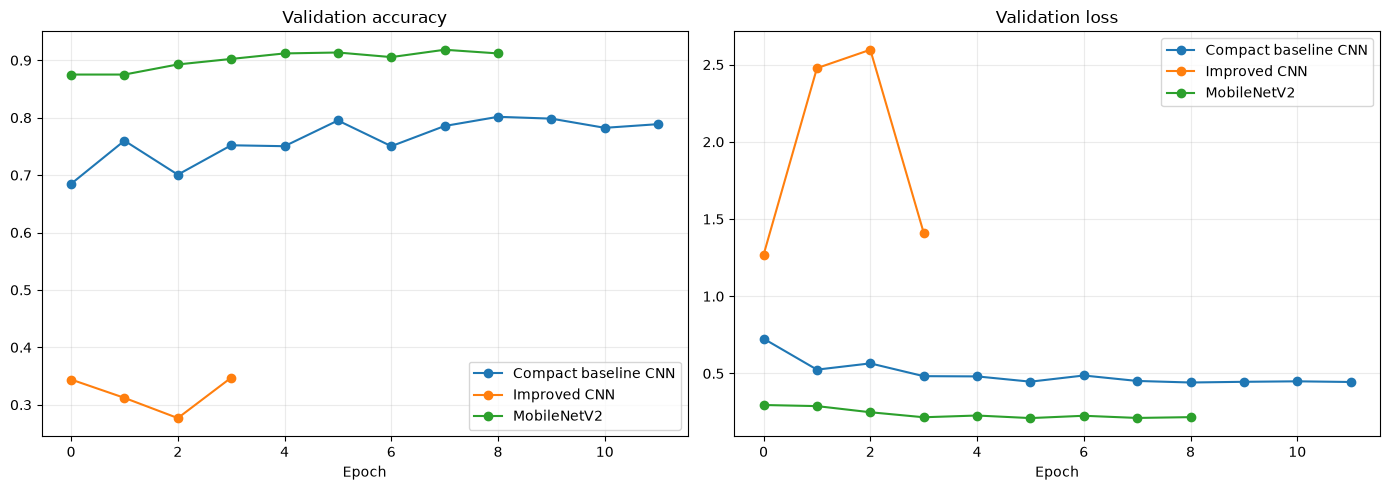

In [62]:
histories_v2 = {
    "Compact baseline CNN": baseline_history_v2,
    "Improved CNN": improved_history_v2,
    "MobileNetV2": mobilenetv2_history_v2,
}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, history in histories_v2.items():
    axes[0].plot(history.history["val_accuracy"], marker="o", label=name)
    axes[1].plot(history.history["val_loss"], marker="o", label=name)
axes[0].set_title("Validation accuracy")
axes[1].set_title("Validation loss")
for axis in axes:
    axis.set_xlabel("Epoch")
    axis.grid(alpha=0.25)
    axis.legend()
plt.tight_layout()
plt.show()

### 10.2 Accuracy, precision, recall, and macro F1 on the common test set

Accuracy can hide a weak disease class. Macro precision, recall, and F1 weight each class equally, so they provide a better comparison for this multi-class problem.

In [65]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models_v2 = {
    "Compact baseline CNN": baseline_cnn_v2,
    "Improved CNN": improved_cnn_v2,
    "MobileNetV2": mobilenetv2_model_v2,
}

def collect_predictions(model, dataset):
    true_labels, predicted_labels = [], []
    for images, labels in dataset:
        probabilities = model.predict(images, verbose=0)
        true_labels.extend(labels.numpy().tolist())
        predicted_labels.extend(np.argmax(probabilities, axis=1).tolist())
    return np.array(true_labels), np.array(predicted_labels)

results_v2, reports_v2, confusion_matrices_v2 = [], {}, {}
for model_name, current_model in models_v2.items():
    y_true_v2, y_pred_v2 = collect_predictions(current_model, test_ds_v2)
    report = classification_report(
        y_true_v2, y_pred_v2, target_names=class_names,
        labels=np.arange(num_classes), output_dict=True, zero_division=0
    )
    reports_v2[model_name] = report
    confusion_matrices_v2[model_name] = confusion_matrix(
        y_true_v2, y_pred_v2, labels=np.arange(num_classes)
    )
    results_v2.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_true_v2, y_pred_v2),
        "Macro Precision": report["macro avg"]["precision"],
        "Macro Recall": report["macro avg"]["recall"],
        "Macro F1": report["macro avg"]["f1-score"],
    })
comparison_df_v2 = pd.DataFrame(results_v2).sort_values("Macro F1", ascending=False)
display(comparison_df_v2.round(4))

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
2,MobileNetV2,0.9344,0.9151,0.9191,0.9170
0,Compact baseline CNN,0.8080,0.7622,0.7675,0.7614
1,Improved CNN,0.3664,0.3438,0.3086,0.2842


### 10.3 Per-class precision, recall, and F1

In [66]:
for model_name, report in reports_v2.items():
    print(f"\n{model_name}")
    per_class_df = pd.DataFrame(report).T.loc[
        class_names, ["precision", "recall", "f1-score", "support"]
    ]
    display(per_class_df.round(4))


Compact baseline CNN


,precision,recall,f1-score,support
Blight,0.7407,0.5882,0.6557,170.0
Common_Rust,0.8910,0.9641,0.9261,195.0
Gray_Leaf_Spot,0.4510,0.5349,0.4894,86.0
Healthy,0.9661,0.9828,0.9744,174.0



Improved CNN


,precision,recall,f1-score,support
Blight,0.1169,0.0529,0.0729,170.0
Common_Rust,0.2919,0.6872,0.4098,195.0
Gray_Leaf_Spot,0.0000,0.0000,0.0000,86.0
Healthy,0.9663,0.4943,0.6540,174.0



MobileNetV2


,precision,recall,f1-score,support
Blight,0.8869,0.8765,0.8817,170.0
Common_Rust,0.9845,0.9744,0.9794,195.0
Gray_Leaf_Spot,0.7889,0.8256,0.8068,86.0
Healthy,1.0000,1.0000,1.0000,174.0


### 10.4 Confusion matrices

The diagonal contains correct predictions. Off-diagonal cells reveal which diseases are confused, helping guide future data collection and targeted augmentation.

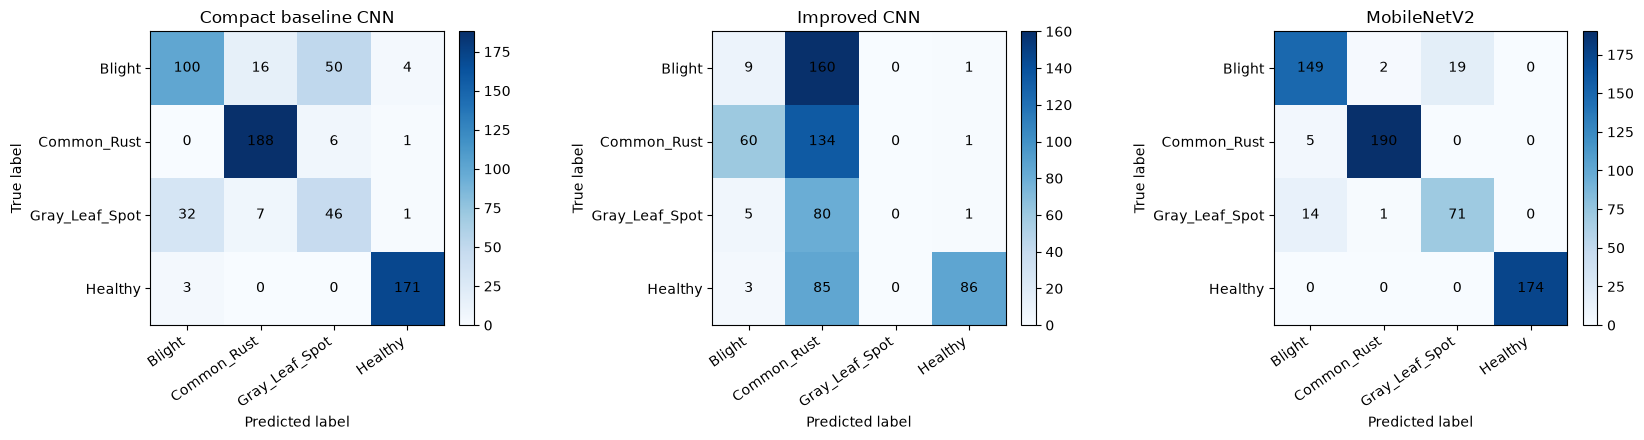

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for axis, (model_name, matrix) in zip(axes, confusion_matrices_v2.items()):
    image = axis.imshow(matrix, cmap="Blues")
    axis.set_title(model_name)
    axis.set_xlabel("Predicted label")
    axis.set_ylabel("True label")
    axis.set_xticks(range(num_classes), class_names, rotation=35, ha="right")
    axis.set_yticks(range(num_classes), class_names)
    for row in range(num_classes):
        for column in range(num_classes):
            axis.text(column, row, matrix[row, column], ha="center", va="center")
    fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 11. Final comparison and model export

### 11.1 Select and save the strongest model

Macro F1 is used for selection because it balances precision and recall equally across all disease classes. Accuracy remains visible in the comparison table.

In [68]:
best_model_name_v2 = comparison_df_v2.iloc[0]["Model"]
best_model_v2 = models_v2[best_model_name_v2]
best_row_v2 = comparison_df_v2.iloc[0]
best_model_path_v2 = os.path.join(
    "artifacts", f"best_{best_model_name_v2.lower().replace(' ', '_')}_v2.keras"
)
best_model_v2.save(best_model_path_v2)
print(f"Selected model: {best_model_name_v2}")
print(f"Macro F1: {best_row_v2['Macro F1']:.4f}")
print(f"Test accuracy: {best_row_v2['Accuracy']:.4f}")
print(f"Saved to: {best_model_path_v2}")

Selected model: MobileNetV2
Macro F1: 0.9170
Test accuracy: 0.9344
Saved to: artifacts\best_mobilenetv2_v2.keras
